In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from IPython.display import Latex, HTML, Math, display
from uncertainties import ufloat
from uncertainties.umath import sqrt
from uncertainties import unumpy as unp
from scipy.stats import linregress
from scipy.optimize import curve_fit
from uncertainties.umath import sin, radians 
from uncertainties.umath import *
from scipy.signal import savgol_filter, find_peaks

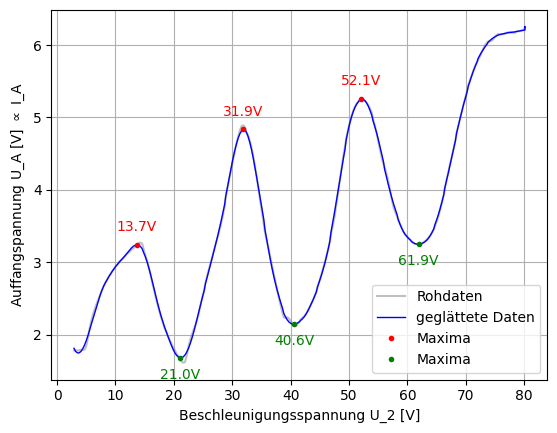

Maxima gefunden bei: [13.7 31.9 52.1] [V]
Minima gefunden bei: [21.  40.6 61.9] [V]

Mittelwert Abstände Maxima: 19.200 [V]
Mittelwert Abstände Minima: 20.450 [V]
Abschätzung der Anregungsenergien: 19.825 [eV]

Analyse Leuchtzonen
Unterschied zwischen Zone 1 und 2: 20.650 [V]
Unterschied zwischen Zone 2 und 3: 18.050 [V]

Mittlerer Unterschied: 19.350 [V] = Anregungsenergie [eV]


In [31]:
# 1. Franck-Hertz-Versuch

#daten aus csv laden
data = pd.read_excel("Do01_PS9.ods", engine="odf")           #csv file aus CASSY/OceanView?
I_A = data["U_B1 / V"].to_numpy()                   #[A] Strom I_A; umrechenen aus der gemessenen Spannung!
U2 = data["U_A1 / V"].to_numpy() * 10                    #[V] Spannung U2

I_A_smooth = savgol_filter(I_A, window_length=21, polyorder=3)          #[A]; daten glätten um min und max zu finden 

#maxima und minima
peaks, _ = find_peaks(I_A_smooth, distance=20, prominence=0.05)         #indizes der maxima

valleys, _ = find_peaks(-I_A_smooth, distance=20, prominence=0.05)      #indizes der minima
valleys = valleys[1:]

#Plot

plt.figure()
plt.plot(U2, I_A, color="grey", alpha=0.5, label="Rohdaten")
plt.plot(U2, I_A_smooth, color="blue", linewidth=1, label="geglättete Daten")
plt.plot(U2[peaks], I_A_smooth[peaks], 'ro', markersize=3, label="Maxima")
for i, v in enumerate(U2[peaks]):
    plt.annotate(f"{v:.1f}V", (U2[peaks][i], I_A_smooth[peaks][i]),
                 textcoords="offset points", xytext=(0, 10), ha="center", color="red")
plt.plot(U2[valleys], I_A_smooth[valleys], 'go', markersize=3, label="Maxima")
for i, v in enumerate(U2[valleys]):
    plt.annotate(f"{v:.1f}V", (U2[valleys][i], I_A_smooth[valleys][i]),
                 textcoords="offset points", xytext=(0, -15), ha="center", color="green")
plt.xlabel("Beschleunigungsspannung U_2 [V]")
plt.ylabel(r"Auffangspannung U_A [V] $\propto$ I_A")
plt.grid(True)
plt.legend()
plt.show()

#ergebnisse
print(f"Maxima gefunden bei: {U2[peaks]} [V]")
print(f"Minima gefunden bei: {U2[valleys]} [V]")
print()

peak_diffs = np.diff(U2[peaks])                 #Abstände zwischen Maxima [V]
valley_diffs = np.diff(U2[valleys])             #Abstände zwischen Minima [V]

combined_avg = np.mean(np.concatenate([peak_diffs, valley_diffs]))  #Mittelwert zwischen allen Abständen [V] (*e = eV)

print(f"Mittelwert Abstände Maxima: {np.mean(peak_diffs):.3f} [V]")
print(f"Mittelwert Abstände Minima: {np.mean(valley_diffs):.3f} [V]")
print(f"Abschätzung der Anregungsenergien: {combined_avg:.3f} [eV]")        #gesamter Mittelwert mit e multipliziert


#Analyse Leuchtzonen
print()
print("Analyse Leuchtzonen")

U_leuchtzonen = np.array([18.3, 38.95, 57])            #[V]

deltas = np.diff(U_leuchtzonen)
for i, delta in enumerate(deltas):
    print(f"Unterschied zwischen Zone {i+1} und {i+2}: {delta:.3f} [V]")

avg_delta = np.mean(deltas)

print()
print(f"Mittlerer Unterschied: {avg_delta:.3f} [V] = Anregungsenergie [eV]")

#Korrelation: 
#zw. 18 und 20: 3p in Ne ~18.7eV --> Fall 3p -> 3s



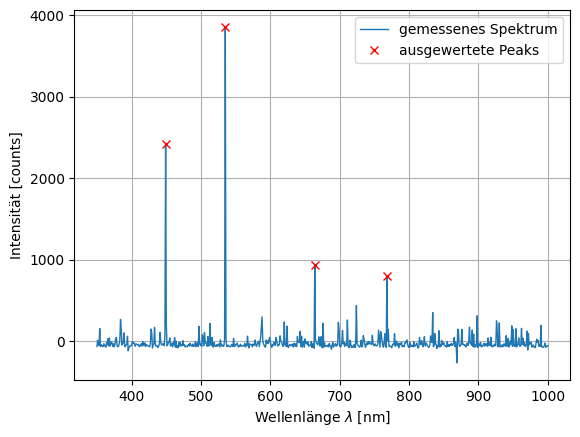

[2.75733333 2.31925234 1.8686747  1.615625  ]


In [ ]:
# 1. Ocean View
h = 4.136 * 10**(-15)                #Plank'sches Wirkungsquantum [Js]
c = 3 * 10**8

data = pd.read_excel("Do01_PS9ocean.ods", engine="odf")     
wave = data["x"].to_numpy()                
inten = data["y"].to_numpy()   

peaks = np.array([449, 535, 664, 768])
indx = peaks - 350

plt.Figure()
plt.plot(wave, inten, linewidth=1, label="gemessenes Spektrum")
plt.plot(peaks, inten[indx], 'x', color="red", label="ausgewertete Peaks")
plt.xlabel(r"Wellenlänge $\lambda$ [nm]")
plt.ylabel("Intensität [counts]")
plt.legend()
plt.grid(True)
plt.show()

# E = (h*c) / lambda

lambdas = np.array([450, 535, 664, 768])*10**(-9)           #Wellenlänge der Peaks [nm]

E = (h * c) / lambdas                                       #Energie [eV]

print(E)

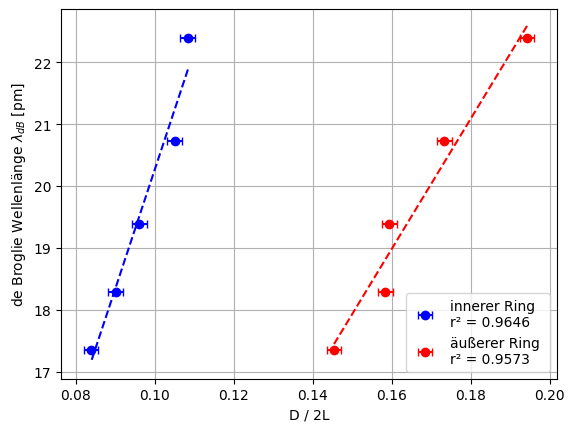

d1: 192+/-21 [pm]
d2: 105+/-13 [pm]


In [38]:
# 2. Elektronenbeugung

#Konstanten
h = 6.626 * 10**(-34)                #Plank'sches Wirkungsquantum [Js]
e = 1.602 * 10**(-19)                #[C] Elementarladung
me = 9.109 * 10**(-31)               #[kg]  Elektronenmasse
L = 13.24 * 10**(-2)                 #[m] Abstand Graphit - Schirm

#Daten
U = np.array([3, 3.5, 4, 4.5, 5])*1000            #[V]

D1 = unp.uarray([2.87, 2.78, 2.545, 2.385, 2.22], 0.05)/100           #[m], Durchmesser innerer Ring
D2 = unp.uarray([5.145, 4.59, 4.22, 4.195, 3.85], 0.05)/100           #[m], Durchmesser äußerer Ring

#Berechnungen
lambdas = h / np.sqrt(2 * me * e * U)           #[m], de Broglie Wellenlänge
lambdas_plot = lambdas * 10**12                 #[m --> pm]

x1 = D1 / (2 * L)           #x-Achsen für D1, dimensionslos
x2 = D2 / (2 * L)           #x-Achsen für D2, dimensionslos

x1_nom = unp.nominal_values(x1)
x1_u = unp.std_devs(x1)

x2_nom = unp.nominal_values(x2)
x2_u = unp.std_devs(x2)

reg1 = linregress(x1_nom, lambdas)
reg2 = linregress(x2_nom, lambdas)

d1 = ufloat(reg1.slope, reg1.stderr) * 10**12       #[m --> pm]
d2 = ufloat(reg2.slope, reg2.stderr) * 10**12       #[m --> pm]

#Plot
plt.figure()
plt.errorbar(x1_nom, lambdas_plot, xerr=x1_u, fmt='o', capsize=3, color="blue", label=f"innerer Ring \nr² = {reg1.rvalue**2:.4f}")
plt.plot(x1_nom, (reg1.slope*x1_nom + reg1.intercept) * 10**12, 'b--')
plt.errorbar(x2_nom, lambdas_plot, xerr=x2_u, fmt='o', capsize=3, color="red", label=f"äußerer Ring \nr² = {reg2.rvalue**2:.4f}")
plt.plot(x2_nom, (reg2.slope*x2_nom + reg2.intercept)* 10 **12, 'r--')
plt.xlabel("D / 2L")
plt.ylabel(r"de Broglie Wellenlänge $\lambda_{dB}$ [pm]")
plt.legend()
plt.grid(True)
plt.show()

print(f"d1: {d1} [pm]")
print(f"d2: {d2} [pm]")


